# Import Libraries

In [5]:
# Setup and Imports ---

import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno # For visualizing missing data

# Get the current working directory of the notebook
notebook_dir = os.getcwd()
oject_root = os.path.abspath(os.path.join(notebook_dir, '..'))

# Add the project root to sys.path
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    print(f"Added project root '{project_root}' to sys.path.")
else:
    print(f"Project root '{project_root}' was already in sys.path.")

# Now you can import from src
try:
    from src.config import RAW_DATA_PATH, POLICY_ID_COL, TRANSACTION_MONTH_COL, TOTAL_CLAIMS_COL, TOTAL_PREMIUM_COL, HAS_CLAIM_COL, MARGIN_COL
    from src.data_preparation import load_raw_data # We only need load_raw_data here. engineer_features and handle_missing_data will be called by prepare_data_for_modeling later in the pipeline, but for EDA, we'll do initial cleaning manually in the notebook.
    print("Successfully imported modules from src.")
except ModuleNotFoundError as e:
    print(f"Error importing src modules: {e}")
    print("Please ensure your notebook's working directory is correct or adjust 'project_root' variable.")
    print("Also, confirm that src/config.py and src/data_preparation.py exist in your 'src' folder.")


# Set display options for pandas for better readability in notebooks
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format) # Format floats to 2 decimal places

# Set plotting style for consistent visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

Added project root 'C:\Users\benke\Desktop\DataScience\10Academy\Kefiya_AI_Mastery\Week3\KAIM_W3_Insurance_risk_analysis\KAIM_W03_AlphaCare_Insurance_Risk_Analysis' to sys.path.
Successfully imported modules from src.


In [6]:
# Define the path to your raw data
print("Loading raw data...")
df_raw = load_raw_data(RAW_DATA_PATH)

if df_raw.empty:
    print(f"Failed to load data. The file '{RAW_DATA_PATH}' was not found or is empty.")
    print("Please ensure the file exists at the specified path and src/config.py is correctly configured.")
else:
    print("Data loaded successfully. Displaying first 5 rows:")
    display(df_raw.head())
    print(f"Initial data shape: {df_raw.shape}")

Loading raw data...


C:\Users\benke\Desktop\DataScience\10Academy\Kefiya_AI_Mastery\Week3\KAIM_W3_Insurance_risk_analysis\KAIM_W03_AlphaCare_Insurance_Risk_Analysis\src\data_preparation.py:27: DtypeWarning: Columns (32,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep='|')


Data loaded successfully from C:\Users\benke\Desktop\DataScience\10Academy\Kefiya_AI_Mastery\Week3\KAIM_W3_Insurance_risk_analysis\KAIM_W03_AlphaCare_Insurance_Risk_Analysis\data\raw\MachineLearningRating_v3.txt. Shape: (1000098, 52)
Data loaded successfully. Displaying first 5 rows:


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,PostalCode,MainCrestaZone,SubCrestaZone,ItemType,mmcode,VehicleType,RegistrationYear,make,Model,Cylinders,cubiccapacity,kilowatts,bodytype,NumberOfDoors,VehicleIntroDate,CustomValueEstimate,AlarmImmobiliser,TrackingDevice,CapitalOutstanding,NewVehicle,WrittenOff,Rebuilt,Converted,CrossBorder,NumberOfVehiclesInFleet,SumInsured,TermFrequency,CalculatedPremiumPerTerm,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.00,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.00,2597.00,130.00,S/D,4.00,6/2002,119300.00,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.00,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.93,0.00
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.00,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.00,2597.00,130.00,S/D,4.00,6/2002,119300.00,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.00,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.93,0.00
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.00,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.00,2597.00,130.00,S/D,4.00,6/2002,119300.00,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.00,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.00,0.00
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.00,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.00,2597.00,130.00,S/D,4.00,6/2002,119300.00,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,119300.00,Monthly,584.65,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.85,0.00
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.00,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.00,2597.00,130.00,S/D,4.00,6/2002,119300.00,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,119300.00,Monthly,584.65,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.00,0.00


Initial data shape: (1000098, 52)


# Initial Data Cleaning and Feature Derivation (Pre-processing for EDA)

In [7]:
# These steps are replicated from the initial cleaning in run_full_pipeline.py
# to ensure data types are correct for EDA.

print("\n--- Performing initial data cleaning and feature derivation for EDA ---")
df = df_raw.copy()

# List of financial columns that might have comma decimals or be strings
financial_cols = [TOTAL_PREMIUM_COL, TOTAL_CLAIMS_COL, 'CustomValueEstimate',
                  'CapitalOutstanding', 'SumInsured', 'CalculatedPremiumPerTerm']

for col in financial_cols:
    if col in df.columns:
        # Convert to string first to use .str accessor safely
        df[col] = df[col].astype(str)
        # Replace thousands separator (dots) and then decimal comma with period
        df[col] = df[col].str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
        # Convert to numeric, coercing errors to NaN, then fill NaN with 0
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        # Ensure no negative values (clip to 0)
        df[col] = df[col].clip(lower=0)
print("Financial columns cleaned and converted to numeric.")


# Create 'HasClaim' (binary indicator if a policy had any claims)
if TOTAL_CLAIMS_COL in df.columns:
    df[HAS_CLAIM_COL] = (df[TOTAL_CLAIMS_COL] > 0).astype(int)
    print(f"'{HAS_CLAIM_COL}' column created.")

# Create 'Margin' (TotalPremium - TotalClaims)
if TOTAL_PREMIUM_COL in df.columns and TOTAL_CLAIMS_COL in df.columns:
    df[MARGIN_COL] = df[TOTAL_PREMIUM_COL] - df[TOTAL_CLAIMS_COL]
    print(f"'{MARGIN_COL}' column created.")

# Convert date columns to datetime objects for EDA.
# Note: For formal feature engineering in the pipeline, engineer_features from data_preparation.py
# will extract year/month and drop the original date columns. Here, we just convert types.
date_cols_for_eda = [TRANSACTION_MONTH_COL, 'VehicleIntroDate']
for date_col in date_cols_for_eda:
    if date_col in df.columns:
        # Use errors='coerce' to turn unparseable dates into NaT (Not a Time)
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
        print(f"'{date_col}' converted to datetime (errors coerced to NaT).")


# Clean string columns (strip whitespace, convert empty strings to NaN)
# This helps with accurate value counts and imputation later
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip().replace('', np.nan)
print("String columns cleaned (whitespace stripped, empty strings to NaN).")

print("\nCleaned data info (for EDA):")
df.info()
print(f"\nCleaned data shape: {df.shape}")


--- Performing initial data cleaning and feature derivation for EDA ---
Financial columns cleaned and converted to numeric.
'HasClaim' column created.
'Margin' column created.
'TransactionMonth' converted to datetime (errors coerced to NaT).


C:\Users\benke\AppData\Local\Temp\ipykernel_14536\3083434462.py:41: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')


'VehicleIntroDate' converted to datetime (errors coerced to NaT).
String columns cleaned (whitespace stripped, empty strings to NaN).

Cleaned data info (for EDA):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 54 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   UnderwrittenCoverID       1000098 non-null  int64         
 1   PolicyID                  1000098 non-null  int64         
 2   TransactionMonth          1000098 non-null  datetime64[ns]
 3   IsVATRegistered           1000098 non-null  bool          
 4   Citizenship               104888 non-null   object        
 5   LegalType                 1000098 non-null  object        
 6   Title                     1000098 non-null  object        
 7   Language                  1000098 non-null  object        
 8   Bank                      1000098 non-null  object        
 9   AccountType   

# Basic Data Information & Descriptive Statistics

In [8]:
print("Data Info (after initial cleaning for EDA):\n")
df.info()

print("\nDescriptive Statistics for Numerical Features:\n")
# Using .T to transpose for better readability
display(df.select_dtypes(include=np.number).describe().T)

print("\nDescriptive Statistics for Categorical Features:\n")
# Select categorical (object/string) columns
categorical_df = df.select_dtypes(include='object')
if not categorical_df.empty:
    for col in categorical_df.columns:
        print(f"\n--- {col} ---")
        # Include NaN counts by setting dropna=False
        print(categorical_df[col].value_counts(dropna=False))
        print(f"Number of unique values: {categorical_df[col].nunique()}")
else:
    print("No categorical (object) columns found in the DataFrame.")

Data Info (after initial cleaning for EDA):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 54 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   UnderwrittenCoverID       1000098 non-null  int64         
 1   PolicyID                  1000098 non-null  int64         
 2   TransactionMonth          1000098 non-null  datetime64[ns]
 3   IsVATRegistered           1000098 non-null  bool          
 4   Citizenship               104888 non-null   object        
 5   LegalType                 1000098 non-null  object        
 6   Title                     1000098 non-null  object        
 7   Language                  1000098 non-null  object        
 8   Bank                      1000098 non-null  object        
 9   AccountType               1000098 non-null  object        
 10  MaritalStatus             1000098 non-null  object        
 11  Gende

,count,mean,std,min,25%,50%,75%,max
UnderwrittenCoverID,1000098.00,104817.55,63293.71,1.00,55143.00,94083.00,139190.00,301175.00
PolicyID,1000098.00,7956.68,5290.04,14.00,4500.00,7071.00,11077.00,23246.00
PostalCode,1000098.00,3020.60,2649.85,1.00,827.00,2000.00,4180.00,9870.00
mmcode,999546.00,54877704.02,13603805.34,4041200.00,60056925.00,60058415.00,60058418.00,65065350.00
RegistrationYear,1000098.00,2010.23,3.26,1987.00,2008.00,2011.00,2013.00,2015.00
Cylinders,999546.00,4.05,0.29,0.00,4.00,4.00,4.00,10.00
cubiccapacity,999546.00,2466.74,442.80,0.00,2237.00,2694.00,2694.00,12880.00
kilowatts,999546.00,97.21,19.39,0.00,75.00,111.00,111.00,309.00
NumberOfDoors,999546.00,4.02,0.47,0.00,4.00,4.00,4.00,6.00
CustomValueEstimate,1000098.00,509947.18,2902841.21,0.00,0.00,0.00,0.00,265500000.00



Descriptive Statistics for Categorical Features:


--- Citizenship ---
Citizenship
NaN    895210
ZA     103721
ZW        936
AF        231
Name: count, dtype: int64
Number of unique values: 3

--- LegalType ---
LegalType
Individual           911929
Private company       83891
Close Corporation      2459
Public company         1295
Partnership             331
Sole proprieter         193
Name: count, dtype: int64
Number of unique values: 6

--- Title ---
Title
Mr      933555
Mrs      45850
Ms       13269
Miss      6614
Dr         810
Name: count, dtype: int64
Number of unique values: 5

--- Language ---
Language
English    1000098
Name: count, dtype: int64
Number of unique values: 1

--- Bank ---
Bank
First National Bank       260811
ABSA Bank                 204954
Standard Bank             181715
nan                       145961
Nedbank                   132003
Capitec Bank               58155
RMB Private Bank           12576
Ithala Bank                 1730
Investec Bank             

CoverCategory
Passenger Liability                                    104158
Third Party                                            102825
Keys and Alarms                                        102428
Signage and Vehicle Wraps                              102416
Emergency Charges                                      102416
Cleaning and Removal of Accident Debris                102414
Windscreen                                              97313
Own Damage                                              78981
Income Protector                                        60001
Basic Excess Waiver                                     53755
Accidental Death                                        27321
Credit Protection                                       18070
Own Damage.                                             15095
Own damage                                               8776
Windscreen (2015)                                        6450
Income Protector (2015)                                 

# Missing Values Analysis 

In [9]:
print("\n--- Missing Value Analysis ---")
missing_data = df.isnull().sum()
# Filter to show only columns with missing values
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
missing_percentage = (df.isnull().sum() / len(df) * 100)[(df.isnull().sum() / len(df) * 100) > 0].sort_values(ascending=False)

if not missing_data.empty:
    missing_info = pd.DataFrame({
        'Missing Count': missing_data,
        'Missing Percentage (%)': missing_percentage
    })
    print("Columns with Missing Values:")
    display(missing_info)

    # Visualize missing data as a matrix
    print("\n--- Visualizing Missing Data (Matrix) ---")
    msno.matrix(df, figsize=(15, 8), color=(0.2, 0.2, 0.4))
    plt.title('Missing Data Matrix', fontsize=16)
    plt.show()

    # Visualize missing data as a bar plot
    print("\n--- Visualizing Missing Data (Bar Plot) ---")
    msno.bar(df, figsize=(15, 8), color='skyblue')
    plt.title('Missing Data Bar Plot', fontsize=16)
    plt.show()
else:
    print("No missing values found in the DataFrame after initial cleaning.")


--- Missing Value Analysis ---
Columns with Missing Values:


,Missing Count,Missing Percentage (%)
NumberOfVehiclesInFleet,1000098,100.00
Citizenship,895210,89.51
mmcode,552,0.06
Cylinders,552,0.06
cubiccapacity,552,0.06
kilowatts,552,0.06
NumberOfDoors,552,0.06
VehicleIntroDate,552,0.06



--- Visualizing Missing Data (Matrix) ---


NameError: name 'msno' is not defined

# Univariate and Bivariate Analysis (Examples)


--- Univariate and Bivariate Analysis ---


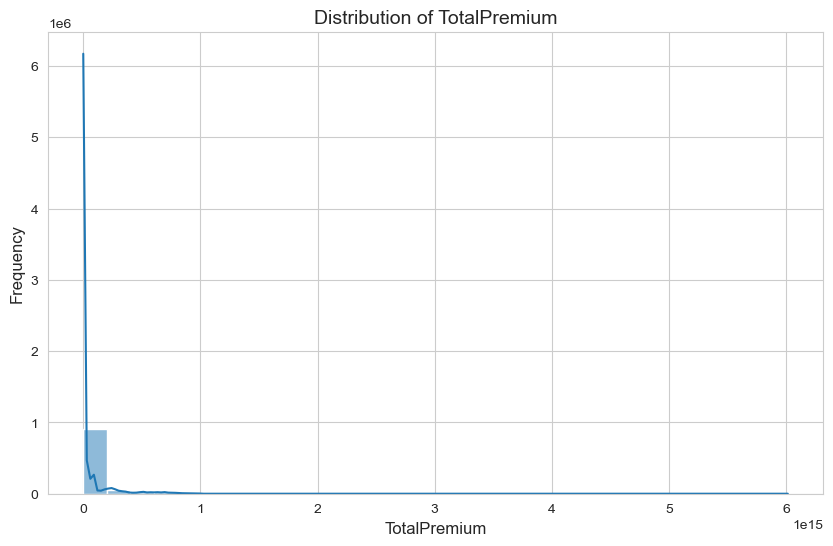

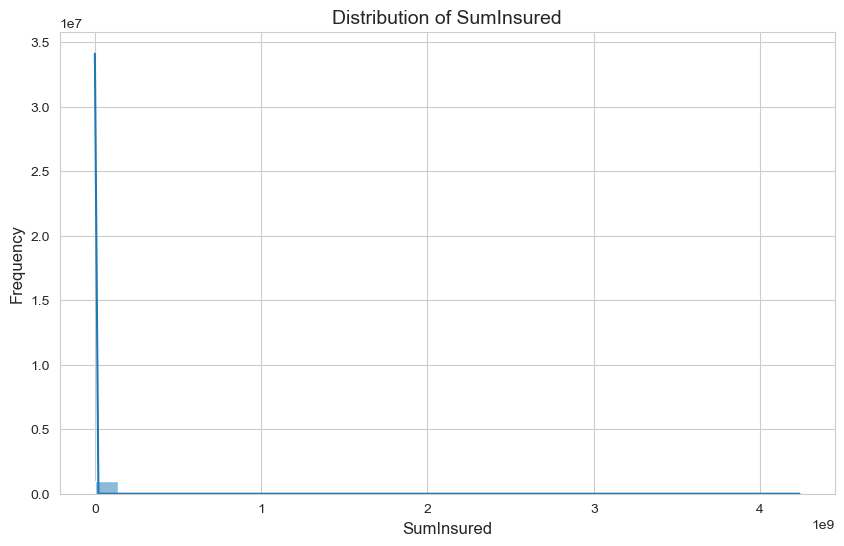

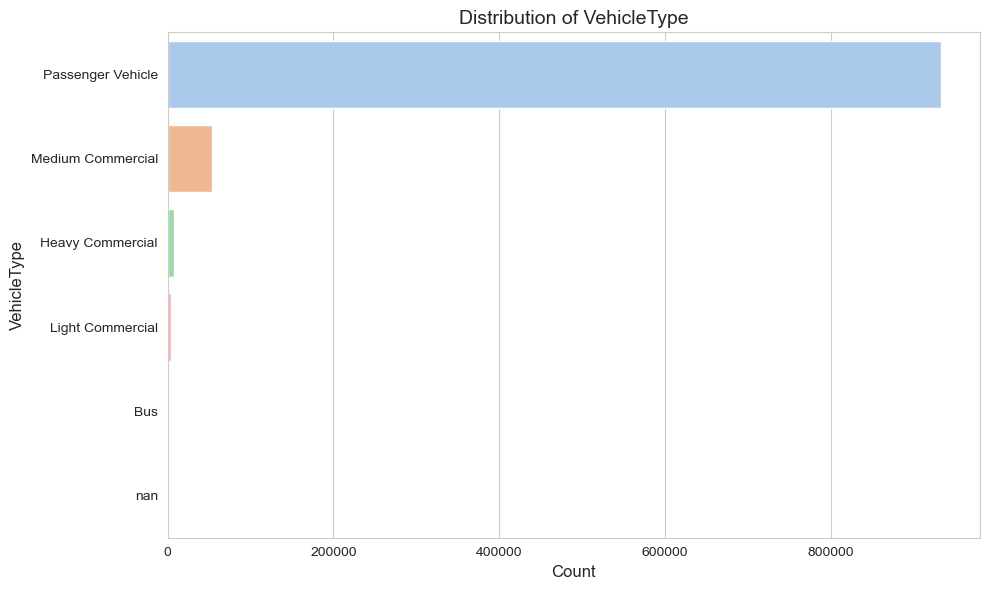

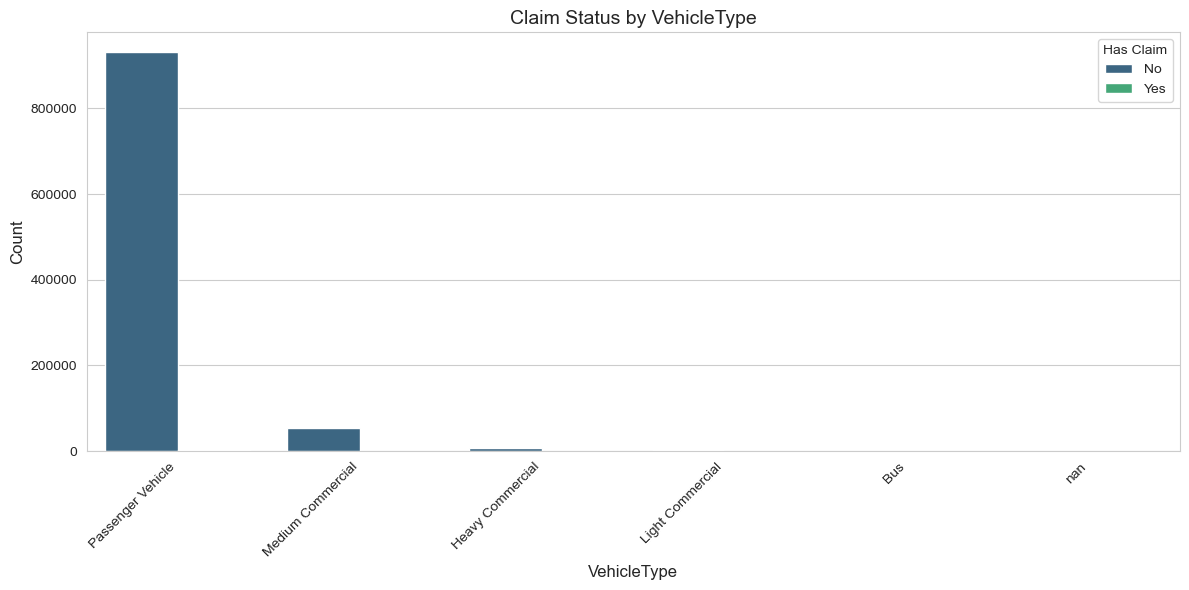


--- Correlation Matrix of Numerical Features ---


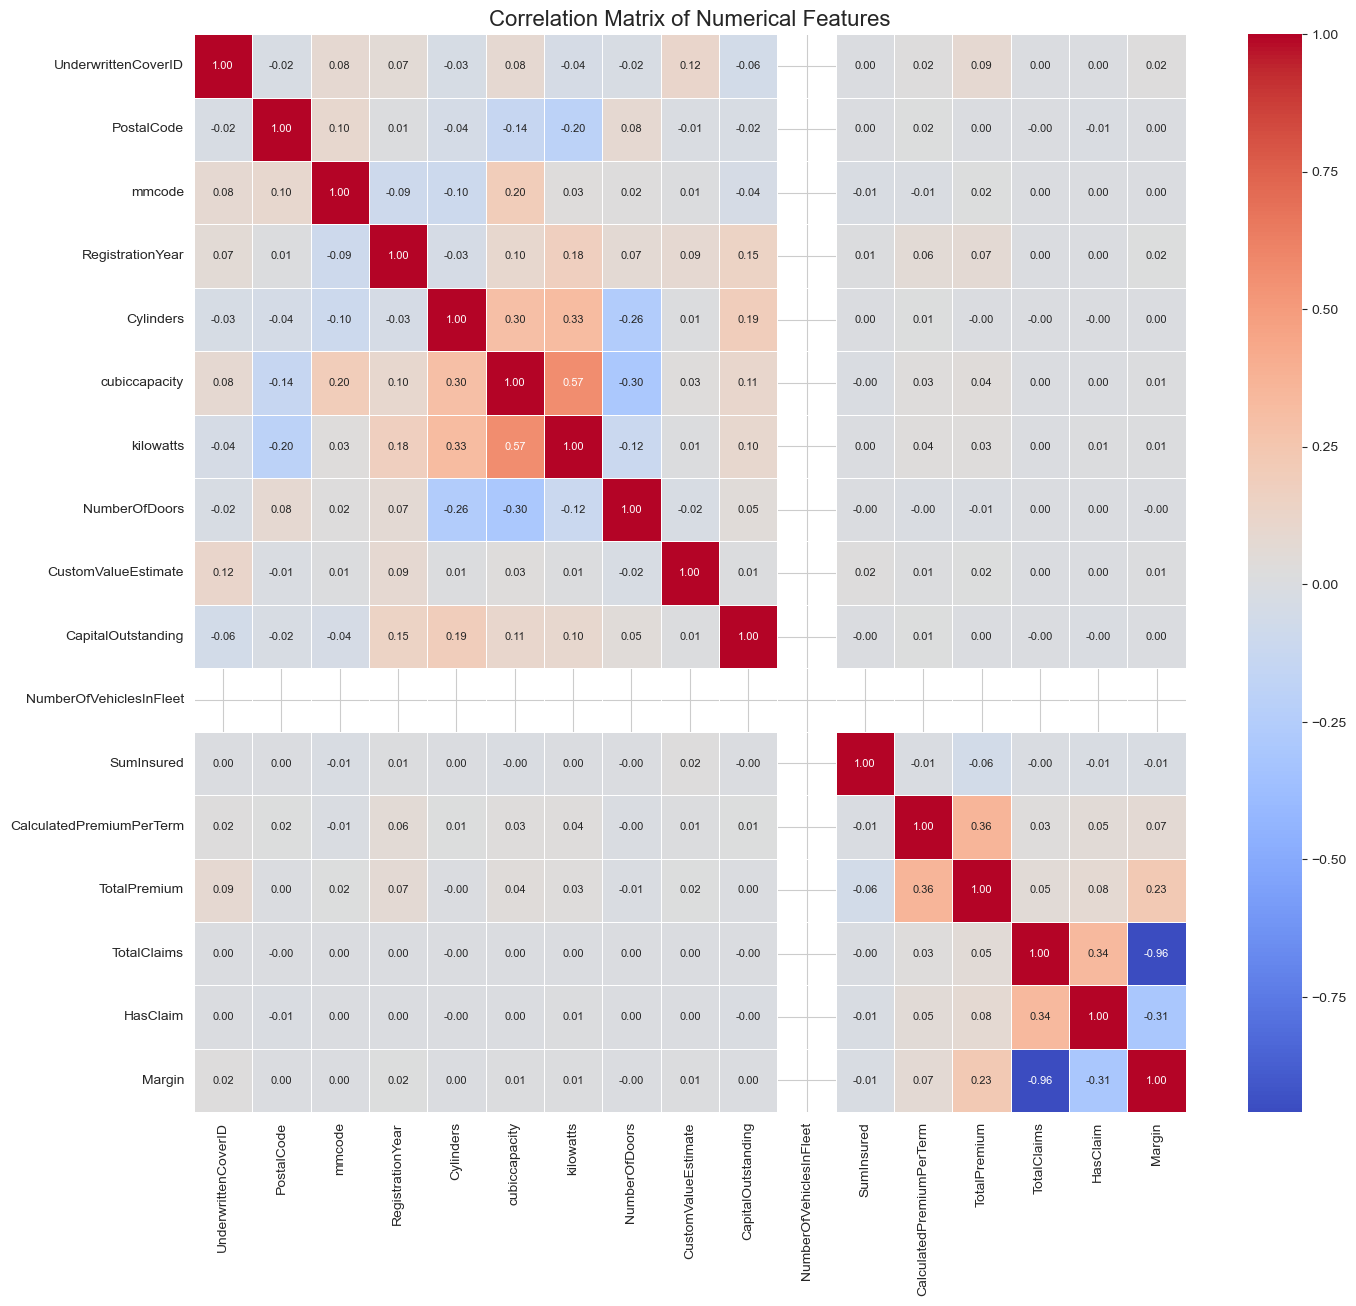


--- EDA Complete ---
This notebook provides a foundational understanding. Further, more specific analyses
can be performed based on initial insights and specific business questions.


In [11]:
print("\n--- Univariate and Bivariate Analysis ---")

# --- Numerical Feature Distributions ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Exclude target/identifier columns if they are in numerical_cols
cols_to_exclude = [TOTAL_CLAIMS_COL, HAS_CLAIM_COL, POLICY_ID_COL, MARGIN_COL]
features_for_dist = [col for col in numerical_cols if col not in cols_to_exclude]

for col in ['Age', 'VehicleAge', 'TotalPremium', 'SumInsured']: # Focus on key numericals
    if col in features_for_dist:
        plt.figure(figsize=(10, 6))
        sns.histplot(df[col], bins=30, kde=True)
        plt.title(f'Distribution of {col}', fontsize=14)
        plt.xlabel(col, fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.show()


# --- Categorical Feature Distributions ---
categorical_cols = df.select_dtypes(include='object').columns.tolist()
# Exclude identifier columns
cat_cols_for_plot = [col for col in categorical_cols if col != POLICY_ID_COL]

for col in ['PolicyType', 'DriverGender', 'VehicleType', 'FuelType']: # Focus on key categoricals
    if col in cat_cols_for_plot:
        plt.figure(figsize=(10, 6))
        sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='pastel')
        plt.title(f'Distribution of {col}', fontsize=14)
        plt.xlabel('Count', fontsize=12)
        plt.ylabel(col, fontsize=12)
        plt.tight_layout()
        plt.show()


# --- Bivariate Analysis: Categorical vs. Target (HasClaim) ---
if HAS_CLAIM_COL in df.columns:
    for col in ['PolicyType', 'DriverGender', 'VehicleType']: # Examples
        if col in cat_cols_for_plot:
            plt.figure(figsize=(12, 6))
            sns.countplot(x=col, hue=HAS_CLAIM_COL, data=df, palette='viridis')
            plt.title(f'Claim Status by {col}', fontsize=14)
            plt.xlabel(col, fontsize=12)
            plt.ylabel('Count', fontsize=12)
            plt.xticks(rotation=45, ha='right')
            plt.legend(title='Has Claim', labels=['No', 'Yes'])
            plt.tight_layout()
            plt.show()


# --- Correlation Matrix for Numerical Features ---
print("\n--- Correlation Matrix of Numerical Features ---")
# Select only numeric columns for correlation (excluding identifiers like PolicyID)
numeric_df = df.select_dtypes(include=np.number)
if POLICY_ID_COL in numeric_df.columns:
    numeric_df = numeric_df.drop(columns=[POLICY_ID_COL])

if not numeric_df.empty:
    correlation_matrix = numeric_df.corr()
    plt.figure(figsize=(16, 14)) # Slightly larger for more features
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={"size": 8})
    plt.title('Correlation Matrix of Numerical Features', fontsize=16)
    plt.show()
else:
    print("No numerical columns found for correlation matrix after exclusions.")

print("\n--- EDA Complete ---")
print("This notebook provides a foundational understanding. Further, more specific analyses")
print("can be performed based on initial insights and specific business questions.")

# Loss Ratio Visualizations by Category


--- Visualizing Loss Ratios by Categorical Features ---

Loss Ratio by Vehicle Type (Top 10):


,VehicleType,total_claims,total_premiums,LossRatio
5,nan,21169442159174606,22635889365662796.00,93.52
4,Passenger Vehicle,8369911999260318646,50333512424028921856.00,16.63
3,Medium Commercial,416806532189976478,3297157290189038592.00,12.64
2,Light Commercial,18181079105263177,223860136118799968.00,8.12
1,Heavy Commercial,13680991754542968,425334269967762880.00,3.22
0,Bus,79965350877193,37719787595019640.00,0.21


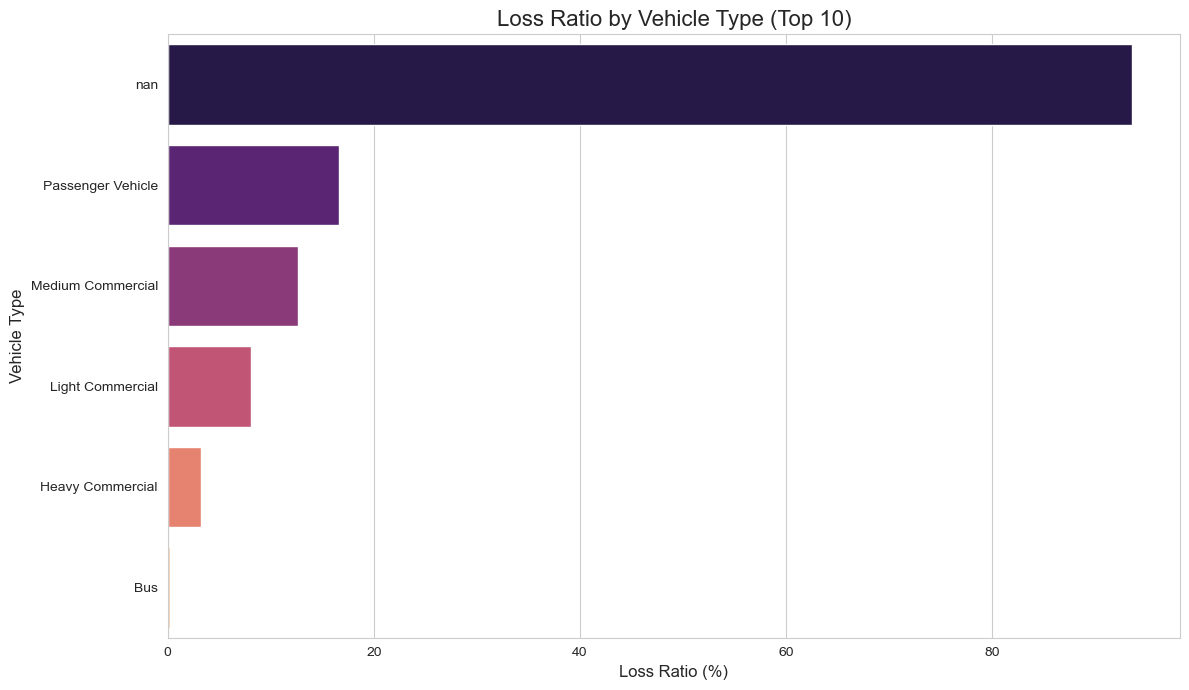

Required columns for DriverGender analysis ('DriverGender', 'TotalClaims', 'TotalPremium') not found.


In [15]:
print("\n--- Visualizing Loss Ratios by Categorical Features ---")

# Define a helper function to calculate loss ratio for a group
# This function handles potential division by zero by returning NaN
# for groups with zero total premiums.
def calculate_loss_ratio_by_group(data, group_col, claims_col, premium_col):
    grouped_data = data.groupby(group_col).agg(
        total_claims=(claims_col, 'sum'),
        total_premiums=(premium_col, 'sum')
    ).reset_index()

    # Calculate Loss Ratio, handling division by zero explicitly
    # If total_premiums is 0, the LossRatio is NaN (Not a Number)
    grouped_data['LossRatio'] = np.where(
        grouped_data['total_premiums'] != 0,
        (grouped_data['total_claims'] / grouped_data['total_premiums']) * 100,
        np.nan
    )
    return grouped_data

# --- Loss Ratio by VehicleType ---
if 'VehicleType' in df.columns and TOTAL_CLAIMS_COL in df.columns and TOTAL_PREMIUM_COL in df.columns:
    loss_ratio_by_vehicle = calculate_loss_ratio_by_group(df, 'VehicleType', TOTAL_CLAIMS_COL, TOTAL_PREMIUM_COL)

    # Filter out rows where LossRatio is NaN (i.e., total_premiums was 0 for that VehicleType)
    # This prevents infinite bars on the plot.
    loss_ratio_by_vehicle = loss_ratio_by_vehicle.dropna(subset=['LossRatio'])

    # Sort by LossRatio in descending order and get the Top N types
    N_TOP_VEHICLE_TYPES = 10 # You can adjust this number
    top_N_vehicle_types = loss_ratio_by_vehicle.sort_values(by='LossRatio', ascending=False).head(N_TOP_VEHICLE_TYPES)

    print(f"\nLoss Ratio by Vehicle Type (Top {N_TOP_VEHICLE_TYPES}):")
    display(top_N_vehicle_types)

    # Create the bar plot for Vehicle Type Loss Ratios
    plt.figure(figsize=(12, 7))
    sns.barplot(x='LossRatio', y='VehicleType', data=top_N_vehicle_types, palette='magma')
    plt.title(f'Loss Ratio by Vehicle Type (Top {N_TOP_VEHICLE_TYPES})', fontsize=16)
    plt.xlabel('Loss Ratio (%)', fontsize=12)
    plt.ylabel('Vehicle Type', fontsize=12)
    plt.xlim(left=0) # Ensure x-axis starts at 0
    plt.tight_layout()
    plt.show()

    if loss_ratio_by_vehicle.isnull().any().any():
        print(f"Note: Some VehicleTypes had zero premiums and were excluded from the plot.")
else:
    print("Required columns for VehicleType analysis ('VehicleType', 'TotalClaims', 'TotalPremium') not found.")


# --- Loss Ratio by DriverGender ---
if 'DriverGender' in df.columns and TOTAL_CLAIMS_COL in df.columns and TOTAL_PREMIUM_COL in df.columns:
    loss_ratio_by_gender = calculate_loss_ratio_by_group(df, 'DriverGender', TOTAL_CLAIMS_COL, TOTAL_PREMIUM_COL)
    
    # Filter out rows where LossRatio is NaN (i.e., total_premiums was 0 for that DriverGender)
    loss_ratio_by_gender = loss_ratio_by_gender.dropna(subset=['LossRatio'])

    print(f"\nLoss Ratio by Driver Gender:")
    display(loss_ratio_by_gender)

    # Create the bar plot for Driver Gender Loss Ratios
    plt.figure(figsize=(8, 5))
    sns.barplot(x='DriverGender', y='LossRatio', data=loss_ratio_by_gender, palette='cividis')
    plt.title('Loss Ratio by Driver Gender', fontsize=16)
    plt.xlabel('Driver Gender', fontsize=12)
    plt.ylabel('Loss Ratio (%)', fontsize=12)
    plt.ylim(bottom=0) # Ensure y-axis starts at 0
    plt.tight_layout()
    plt.show()

    if loss_ratio_by_gender.isnull().any().any():
        print(f"Note: Some DriverGenders had zero premiums and were excluded from the plot.")
else:
    print("Required columns for DriverGender analysis ('DriverGender', 'TotalClaims', 'TotalPremium') not found.")

# Temporal Trends


--- Temporal Trends Analysis ---


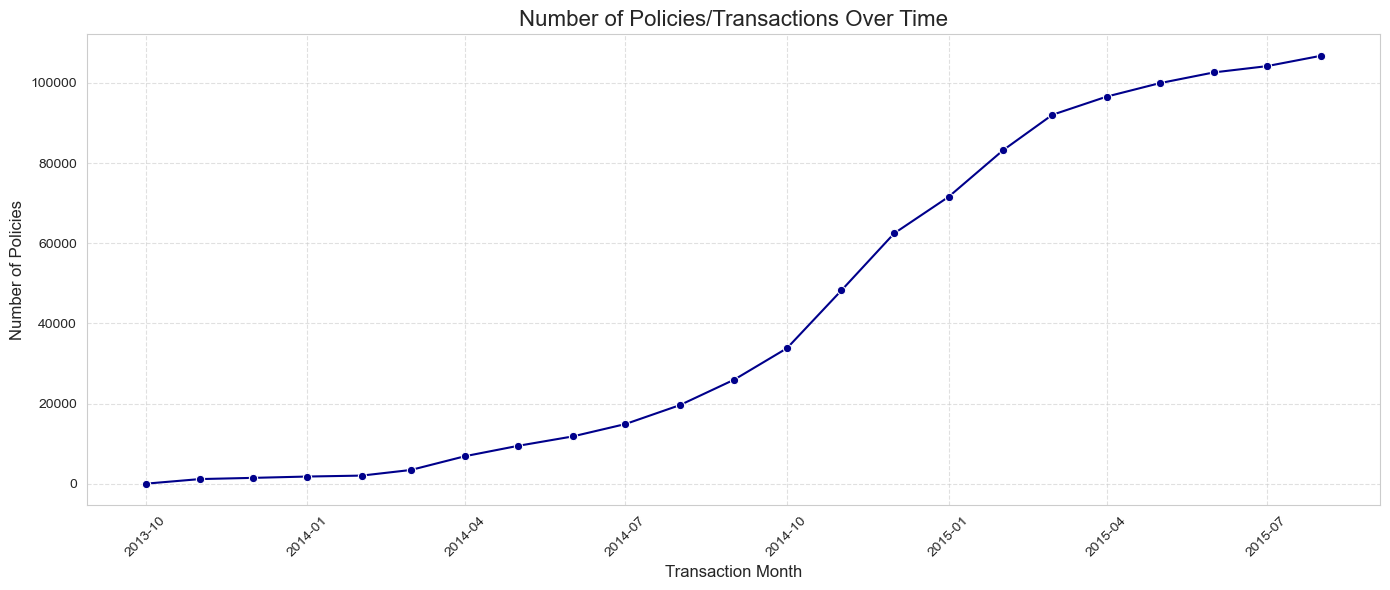

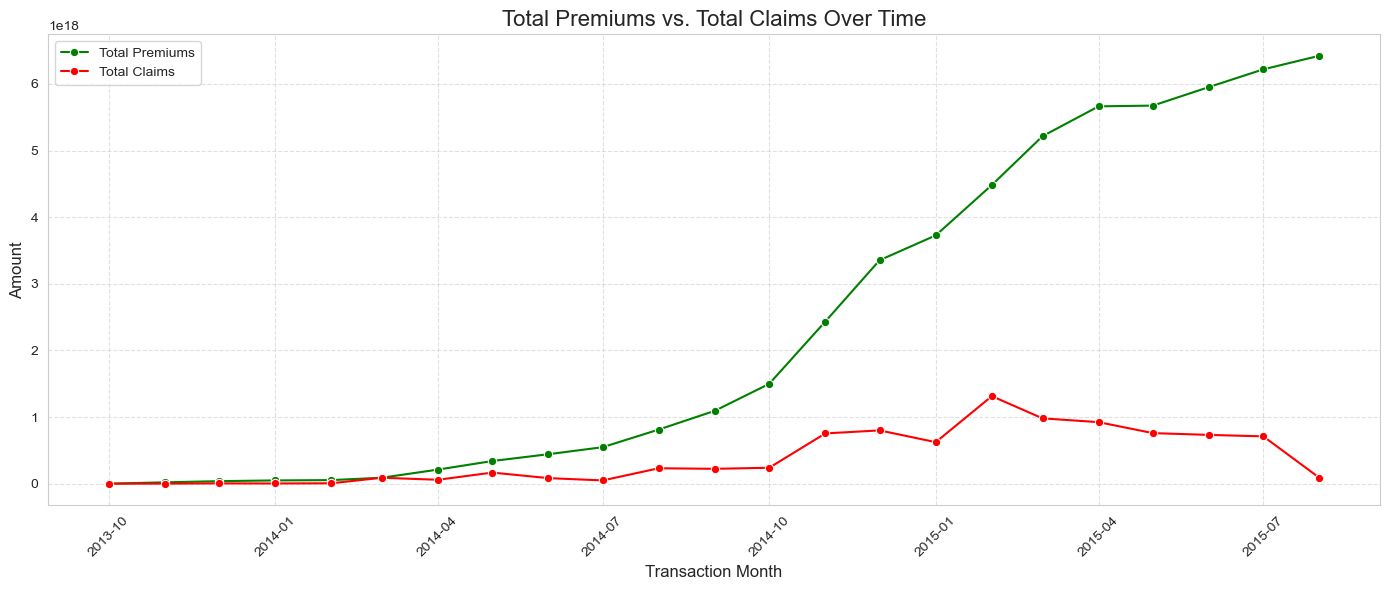

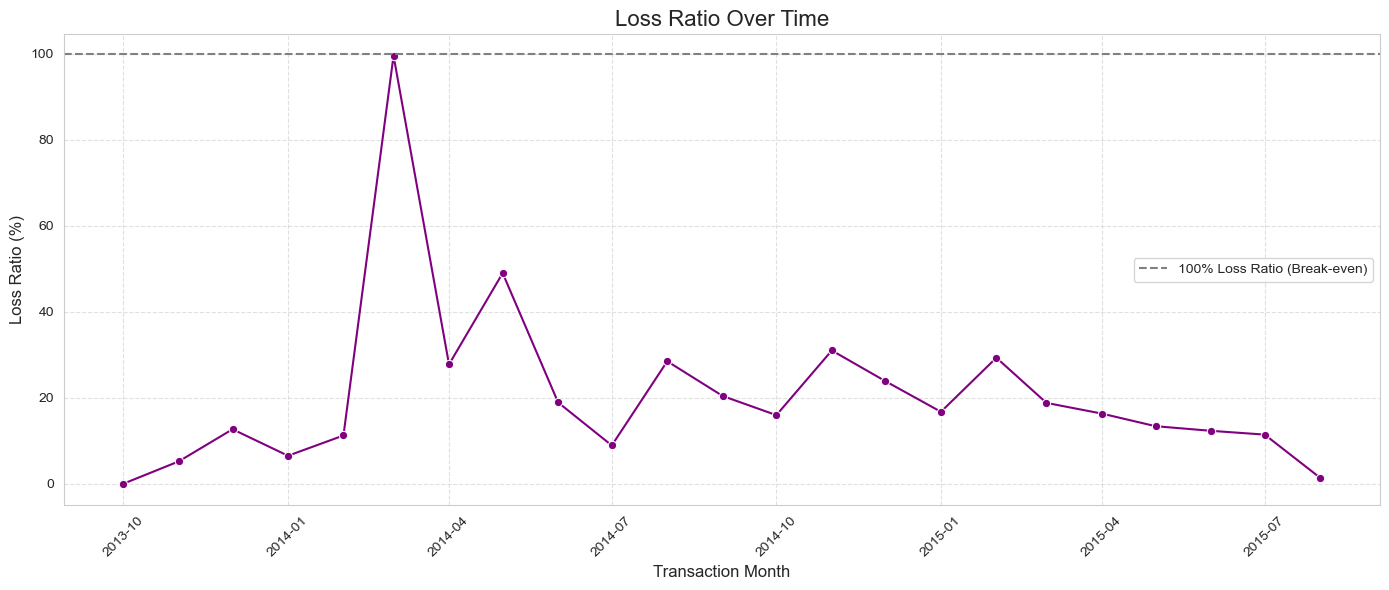


--- Average Monthly Loss Ratio (Seasonal Pattern) ---


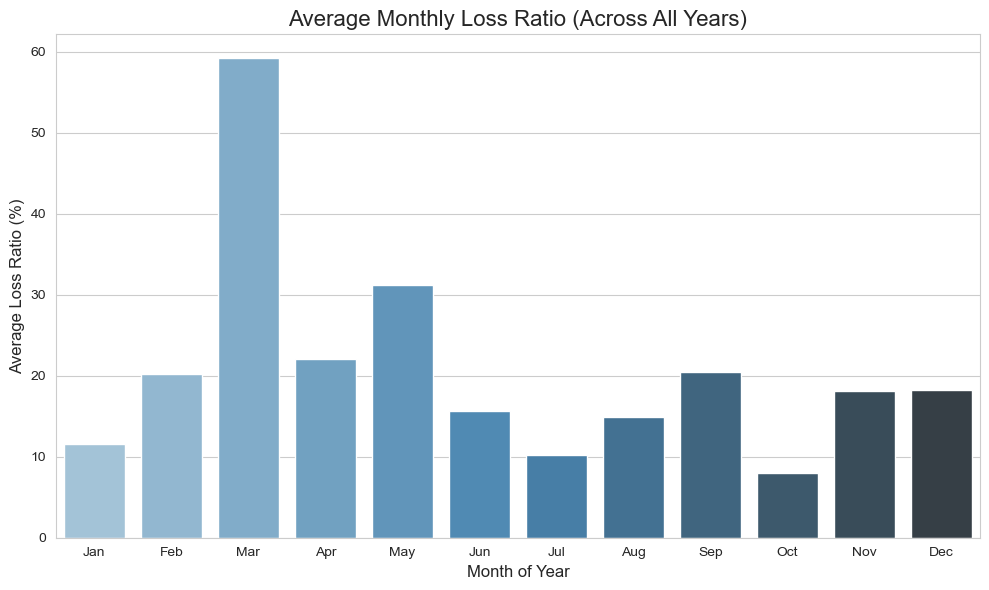


--- Temporal Trends Analysis Complete ---


In [16]:
print("\n--- Temporal Trends Analysis ---")

if TRANSACTION_MONTH_COL in df.columns and pd.api.types.is_datetime64_any_dtype(df[TRANSACTION_MONTH_COL]):
    # Group by TransactionMonth to get time-based aggregates
    temporal_data = df.groupby(TRANSACTION_MONTH_COL).agg(
        num_policies=('PolicyID', 'count'), # Assuming PolicyID uniquely identifies a policy/transaction
        total_premiums=(TOTAL_PREMIUM_COL, 'sum'),
        total_claims=(TOTAL_CLAIMS_COL, 'sum')
    ).reset_index()

    # Calculate Loss Ratio over time, handling division by zero explicitly
    temporal_data['LossRatio'] = np.where(
        temporal_data['total_premiums'] != 0,
        (temporal_data['total_claims'] / temporal_data['total_premiums']) * 100,
        np.nan # Use NaN for months where total premiums were zero
    )

    # Sort by TransactionMonth to ensure plots are in chronological order
    temporal_data = temporal_data.sort_values(by=TRANSACTION_MONTH_COL)

    # Plot 1: Number of Policies/Transactions Over Time
    plt.figure(figsize=(14, 6))
    sns.lineplot(x=TRANSACTION_MONTH_COL, y='num_policies', data=temporal_data, marker='o', color='darkblue')
    plt.title('Number of Policies/Transactions Over Time', fontsize=16)
    plt.xlabel('Transaction Month', fontsize=12)
    plt.ylabel('Number of Policies', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Plot 2: Total Premium and Total Claims Over Time
    plt.figure(figsize=(14, 6))
    sns.lineplot(x=TRANSACTION_MONTH_COL, y='total_premiums', data=temporal_data, marker='o', label='Total Premiums', color='green')
    sns.lineplot(x=TRANSACTION_MONTH_COL, y='total_claims', data=temporal_data, marker='o', label='Total Claims', color='red')
    plt.title('Total Premiums vs. Total Claims Over Time', fontsize=16)
    plt.xlabel('Transaction Month', fontsize=12)
    plt.ylabel('Amount', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot 3: Loss Ratio Over Time
    plt.figure(figsize=(14, 6))
    sns.lineplot(x=TRANSACTION_MONTH_COL, y='LossRatio', data=temporal_data, marker='o', color='purple')
    # Add a horizontal line at 100% to easily see break-even point
    plt.axhline(y=100, color='grey', linestyle='--', label='100% Loss Ratio (Break-even)')
    plt.title('Loss Ratio Over Time', fontsize=16)
    plt.xlabel('Transaction Month', fontsize=12)
    plt.ylabel('Loss Ratio (%)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Optional Plot: Average Monthly Loss Ratio (Across All Years)
    # This helps identify any seasonal patterns regardless of year-specific fluctuations
    print("\n--- Average Monthly Loss Ratio (Seasonal Pattern) ---")
    if not temporal_data.empty:
        temporal_data['Month_of_Year'] = temporal_data[TRANSACTION_MONTH_COL].dt.month
        # Calculate mean LossRatio for each month across all years
        monthly_avg_loss_ratio = temporal_data.groupby('Month_of_Year')['LossRatio'].mean().reset_index()

        # Only plot if there is valid data (not all NaNs)
        if not monthly_avg_loss_ratio.dropna().empty:
            plt.figure(figsize=(10, 6))
            sns.barplot(x='Month_of_Year', y='LossRatio', data=monthly_avg_loss_ratio, palette='Blues_d')
            plt.title('Average Monthly Loss Ratio (Across All Years)', fontsize=16)
            plt.xlabel('Month of Year', fontsize=12)
            plt.ylabel('Average Loss Ratio (%)', fontsize=12)
            # Make x-axis labels more readable
            month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
            plt.xticks(ticks=np.arange(len(month_names)), labels=month_names)
            plt.tight_layout()
            plt.show()
        else:
            print("Not enough data points with valid LossRatio to plot Average Monthly Loss Ratio.")
    else:
        print("Temporal data is empty, skipping seasonal pattern analysis.")

else:
    print(f"'{TRANSACTION_MONTH_COL}' column not found or not in datetime format. Skipping Temporal Trends Analysis.")

print("\n--- Temporal Trends Analysis Complete ---")

# Vehicle Make/Model Claim Amounts


--- Vehicle Make Claim Analysis ---

Top 15 Vehicle Makes by Number of Policies with Key Claim Metrics:


,num_policies,total_premiums,total_claims,num_claims,ClaimFrequency,AvgClaimSeverity,LossRatio
VehicleType,,,,,,,
Passenger Vehicle,"933,598","50,333,512,424,028,921,856.00","8,369,911,999,260,318,720.00","2,587",0.28%,"3,235,373,791,751,186.00",16.63%
Medium Commercial,"53,985","3,297,157,290,189,038,592.00","416,806,532,189,976,448.00",158,0.29%,"2,638,016,026,518,838.50",12.64%
Heavy Commercial,"7,401","425,334,269,967,762,880.00","13,680,991,754,542,968.00",21,0.28%,"651,475,797,835,379.38",3.22%
Light Commercial,"3,897","223,860,136,118,799,968.00","18,181,079,105,263,176.00",8,0.21%,"2,272,634,888,157,897.00",8.12%
Bus,665,"37,719,787,595,019,640.00","79,965,350,877,193.00",1,0.15%,"79,965,350,877,193.00",0.21%
nan,552,"22,635,889,365,662,796.00","21,169,442,159,174,608.00",13,2.36%,"1,628,418,627,628,816.00",93.52%


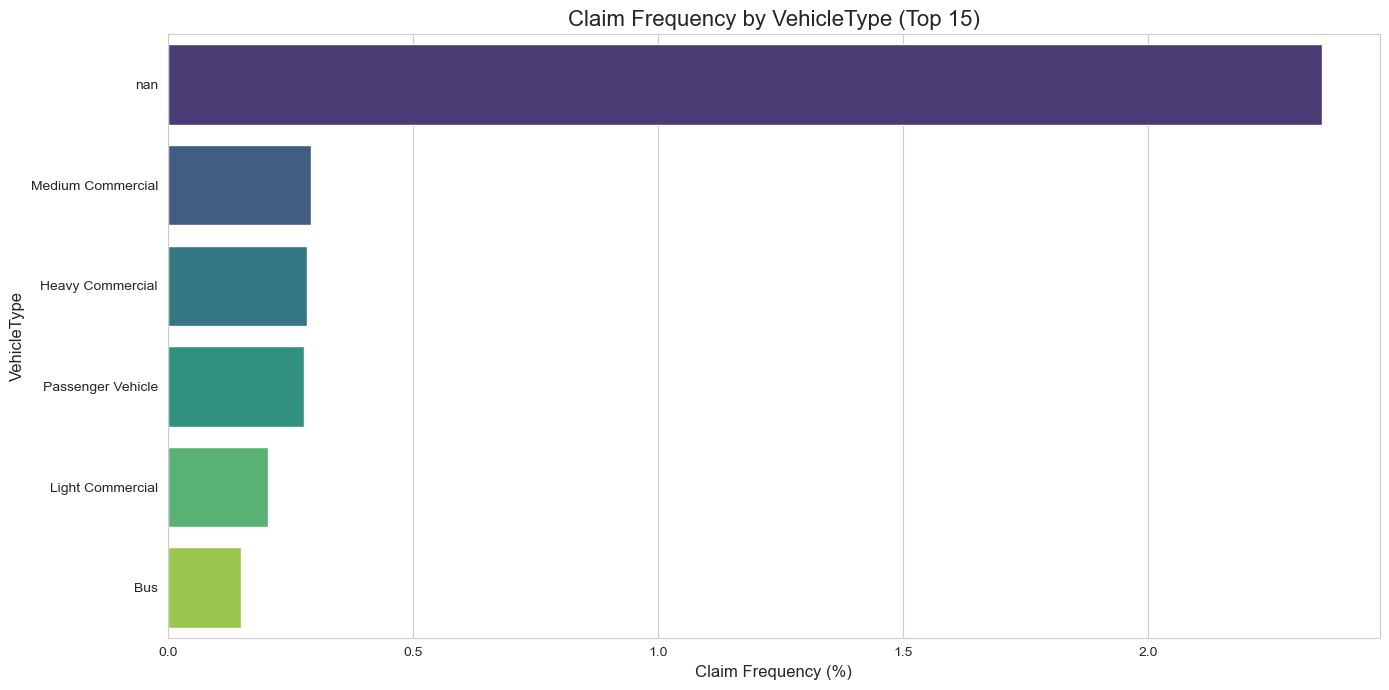

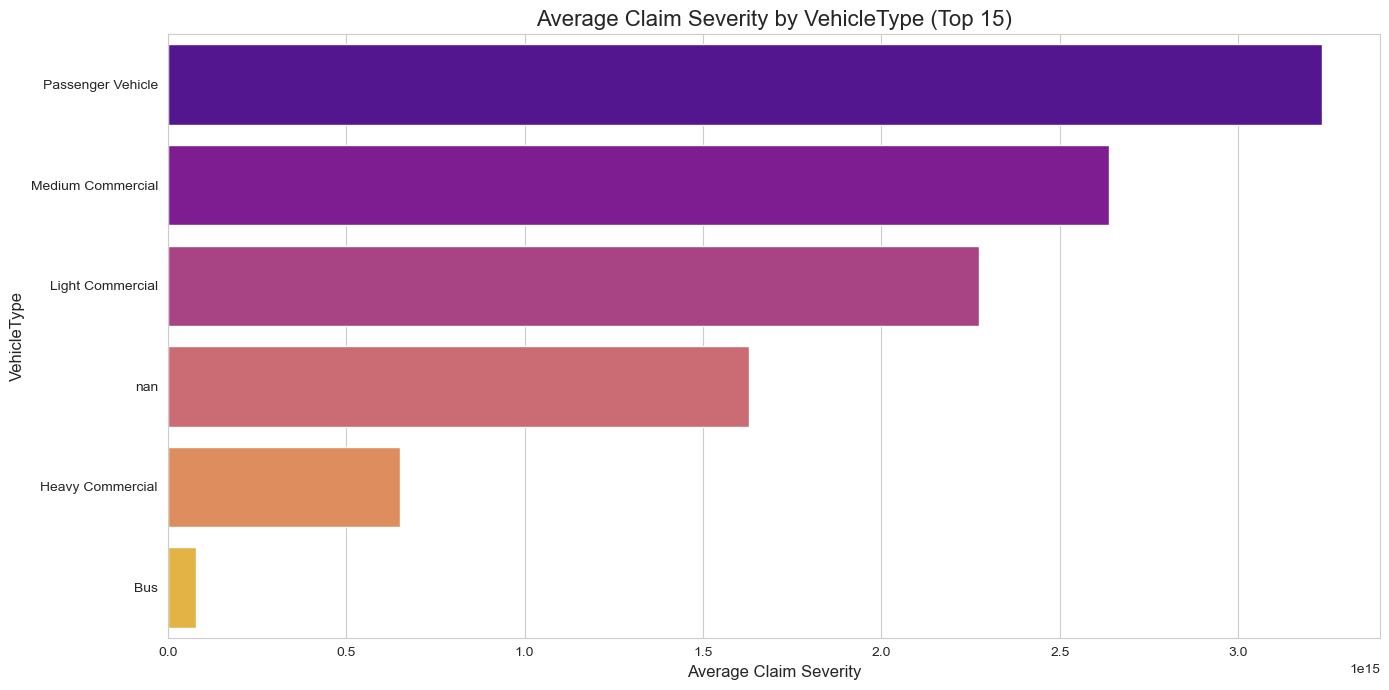


--- Vehicle Make Claim Analysis Complete ---


In [18]:
print("\n--- Vehicle Make Claim Analysis ---")

# Define the column to be used for vehicle make analysis.
# Assuming 'VehicleType' from your dataset serves as the 'Vehicle Make'.
VEHICLE_MAKE_COL = 'VehicleType'

required_cols_for_analysis = [VEHICLE_MAKE_COL, TOTAL_CLAIMS_COL, TOTAL_PREMIUM_COL, HAS_CLAIM_COL, POLICY_ID_COL]
if all(col in df.columns for col in required_cols_for_analysis):

    # Group the DataFrame by the VEHICLE_MAKE_COL and aggregate relevant metrics
    vehicle_make_analysis = df.groupby(VEHICLE_MAKE_COL).agg(
        num_policies=('PolicyID', 'count'), # Count of policies/records for each make
        total_premiums=(TOTAL_PREMIUM_COL, 'sum'),
        total_claims=(TOTAL_CLAIMS_COL, 'sum'),
        num_claims=(HAS_CLAIM_COL, 'sum') # Sum of 'HasClaim' (1 for claim, 0 for no claim)
    ).reset_index()

    # --- Calculate Derived Insurance Metrics ---

    # Claim Frequency: (Number of Claims / Number of Policies) * 100
    # Handles division by zero: if num_policies is 0, frequency is NaN
    vehicle_make_analysis['ClaimFrequency'] = np.where(
        vehicle_make_analysis['num_policies'] != 0,
        (vehicle_make_analysis['num_claims'] / vehicle_make_analysis['num_policies']) * 100,
        np.nan
    )

    # Average Claim Severity: Total Claims / Number of Claims
    # Handles division by zero: if num_claims is 0, severity is NaN
    vehicle_make_analysis['AvgClaimSeverity'] = np.where(
        vehicle_make_analysis['num_claims'] != 0,
        vehicle_make_analysis['total_claims'] / vehicle_make_analysis['num_claims'],
        np.nan
    )

    # Loss Ratio: (Total Claims / Total Premiums) * 100
    # Handles division by zero: if total_premiums is 0, loss ratio is NaN
    vehicle_make_analysis['LossRatio'] = np.where(
        vehicle_make_analysis['total_premiums'] != 0,
        (vehicle_make_analysis['total_claims'] / vehicle_make_analysis['total_premiums']) * 100,
        np.nan
    )

    # Filter out entries that might have no policies or entirely NaN derived metrics
    # This helps to clean up the analysis and visualizations.
    vehicle_make_analysis = vehicle_make_analysis.dropna(subset=['LossRatio', 'ClaimFrequency', 'AvgClaimSeverity'], how='all')

    # Sort the vehicle makes to focus on the most common ones (by number of policies)
    N_TOP_MAKES = 15 # Define the number of top vehicle makes to display
    top_N_vehicle_makes = vehicle_make_analysis.sort_values(by='num_policies', ascending=False).head(N_TOP_MAKES)

    print(f"\nTop {N_TOP_MAKES} Vehicle Makes by Number of Policies with Key Claim Metrics:")
    # Display the table formatted for readability
    display(top_N_vehicle_makes.set_index(VEHICLE_MAKE_COL).style.format({
        'num_policies': '{:,.0f}',
        'total_premiums': '{:,.2f}',
        'total_claims': '{:,.2f}',
        'num_claims': '{:,.0f}',
        'ClaimFrequency': '{:.2f}%',
        'AvgClaimSeverity': '{:,.2f}',
        'LossRatio': '{:.2f}%'
    }))

    # --- Visualizations for Top N Vehicle Makes ---

    # Plot 1: Claim Frequency by Vehicle Make (Top N)
    # Sort for plotting to show highest frequency at the top
    plt.figure(figsize=(14, 7))
    sns.barplot(x='ClaimFrequency', y=VEHICLE_MAKE_COL, data=top_N_vehicle_makes.sort_values(by='ClaimFrequency', ascending=False), palette='viridis')
    plt.title(f'Claim Frequency by {VEHICLE_MAKE_COL} (Top {N_TOP_MAKES})', fontsize=16)
    plt.xlabel('Claim Frequency (%)', fontsize=12)
    plt.ylabel(VEHICLE_MAKE_COL, fontsize=12)
    plt.xlim(left=0) # Ensure x-axis starts from 0
    plt.tight_layout()
    plt.show()

    # Plot 2: Average Claim Severity by Vehicle Make (Top N)
    # Sort for plotting to show highest severity at the top
    plt.figure(figsize=(14, 7))
    sns.barplot(x='AvgClaimSeverity', y=VEHICLE_MAKE_COL, data=top_N_vehicle_makes.sort_values(by='AvgClaimSeverity', ascending=False), palette='plasma')
    plt.title(f'Average Claim Severity by {VEHICLE_MAKE_COL} (Top {N_TOP_MAKES})', fontsize=16)
    plt.xlabel('Average Claim Severity', fontsize=12)
    plt.ylabel(VEHICLE_MAKE_COL, fontsize=12)
    plt.xlim(left=0) # Ensure x-axis starts from 0
    plt.tight_layout()
    plt.show()

    # Note: Loss Ratio by VehicleType was already covered in Cell 8 for top/bottom,
    # but this cell gives more detailed metrics per vehicle make.

else:
    print(f"Required columns for Vehicle Make Claim Analysis ({required_cols_for_analysis}) not found. Skipping analysis.")

print("\n--- Vehicle Make Claim Analysis Complete ---")

# Outlier Detection (Box Plots for Financials)


--- Outlier Detection for Financial Columns ---
Identifying and quantifying potential outliers using Box Plots and the IQR Method.

Analyzing column: 'TotalPremium'


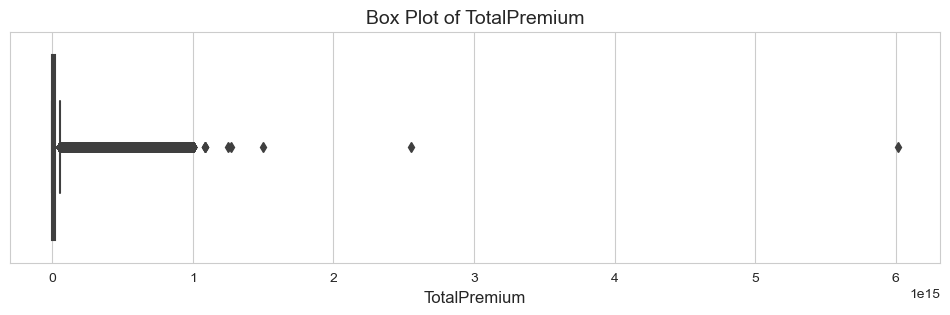

  IQR Method Results for 'TotalPremium':
    Q1 (25th percentile): 0.00
    Q3 (75th percentile): 21,929,824,561,403.00
    IQR (Q3 - Q1): 21,929,824,561,403.00
    Lower Bound (Q1 - 1.5*IQR): -32,894,736,842,104.50
    Upper Bound (Q3 + 1.5*IQR): 54,824,561,403,507.50
    Number of outliers detected: 197881 (19.79% of total data)
    Descriptive statistics of the detected outliers for 'TotalPremium':


count             197881.00
mean     257743503280557.34
std      227392306404100.50
min       54846327108092.00
25%       78947368421052.00
50%      178973771929825.00
75%      347801052631579.00
max     6014324992359933.00
Name: TotalPremium, dtype: float64

    Too many outliers (197881) to list individually.

Analyzing column: 'TotalClaims'


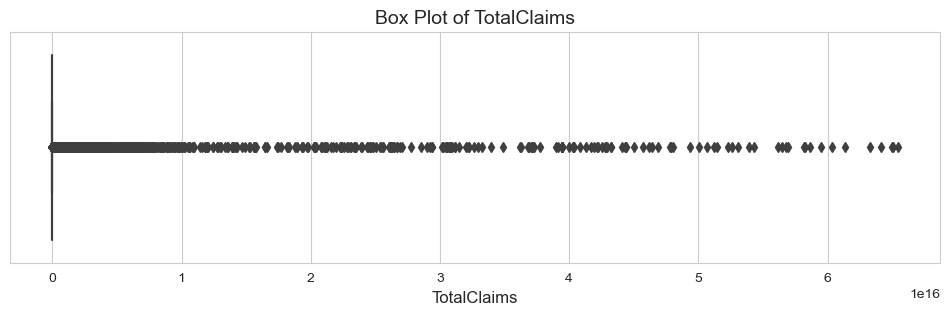

  IQR Method Results for 'TotalClaims':
    Q1 (25th percentile): 0.00
    Q3 (75th percentile): 0.00
    IQR (Q3 - Q1): 0.00
    Lower Bound (Q1 - 1.5*IQR): 0.00
    Upper Bound (Q3 + 1.5*IQR): 0.00
    Number of outliers detected: 2788 (0.28% of total data)
    Descriptive statistics of the detected outliers for 'TotalClaims':


count                2788.00
mean     3170670735229609.50
std      8800825885042510.00
min                  2500.00
25%       116646165350877.25
50%       432151666666666.50
75%       879618991228073.25
max     65423394736842088.00
Name: TotalClaims, dtype: float64

    Too many outliers (2788) to list individually.

Analyzing column: 'Margin'


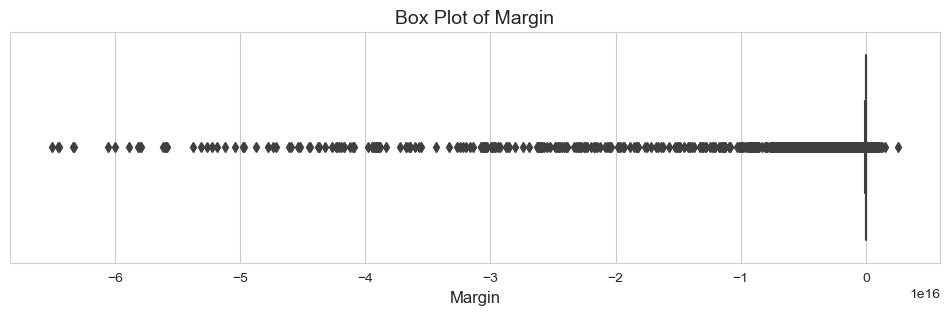

  IQR Method Results for 'Margin':
    Q1 (25th percentile): 0.00
    Q3 (75th percentile): 21,929,824,561,403.00
    IQR (Q3 - Q1): 21,929,824,561,403.00
    Lower Bound (Q1 - 1.5*IQR): -32,894,736,842,104.50
    Upper Bound (Q3 + 1.5*IQR): 54,824,561,403,507.50
    Number of outliers detected: 198562 (19.85% of total data)
    Descriptive statistics of the detected outliers for 'Margin':


count               198562.00
mean       212398322937296.16
std       1122098847422775.62
min     -65015022807017528.00
25%         78947368421052.00
50%        173933684210526.00
75%        342000087719298.00
max       2552414813242783.00
Name: Margin, dtype: float64

    Too many outliers (198562) to list individually.

Analyzing column: 'CustomValueEstimate'


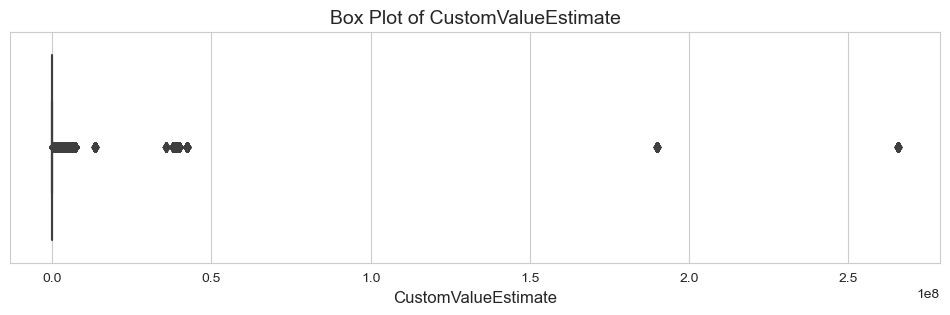

  IQR Method Results for 'CustomValueEstimate':
    Q1 (25th percentile): 0.00
    Q3 (75th percentile): 0.00
    IQR (Q3 - Q1): 0.00
    Lower Bound (Q1 - 1.5*IQR): 0.00
    Upper Bound (Q3 + 1.5*IQR): 0.00
    Number of outliers detected: 220456 (22.04% of total data)
    Descriptive statistics of the detected outliers for 'CustomValueEstimate':


count      220456.00
mean      2313373.89
std       5835653.35
min        200000.00
25%       1350000.00
50%       2200000.00
75%       2801000.00
max     265500000.00
Name: CustomValueEstimate, dtype: float64

    Too many outliers (220456) to list individually.

Analyzing column: 'CapitalOutstanding'


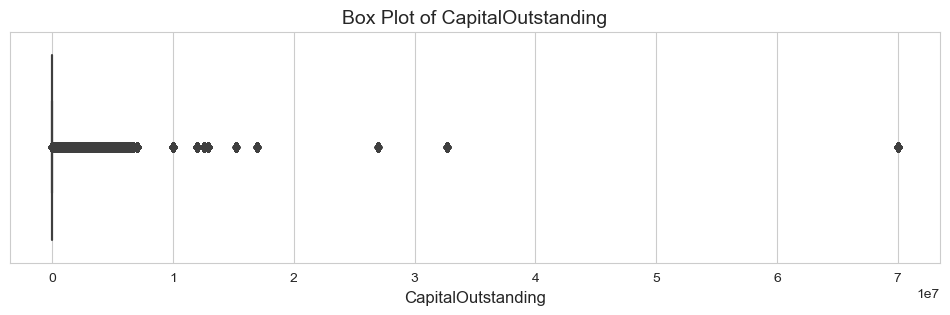

  IQR Method Results for 'CapitalOutstanding':
    Q1 (25th percentile): 0.00
    Q3 (75th percentile): 0.00
    IQR (Q3 - Q1): 0.00
    Lower Bound (Q1 - 1.5*IQR): 0.00
    Upper Bound (Q3 + 1.5*IQR): 0.00
    Number of outliers detected: 207037 (20.70% of total data)
    Descriptive statistics of the detected outliers for 'CapitalOutstanding':


count     207037.00
mean     1745788.14
std      3218108.45
min            1.00
25%       256900.00
50%      1369000.00
75%      2620000.00
max     70000000.00
Name: CapitalOutstanding, dtype: float64

    Too many outliers (207037) to list individually.

Analyzing column: 'SumInsured'


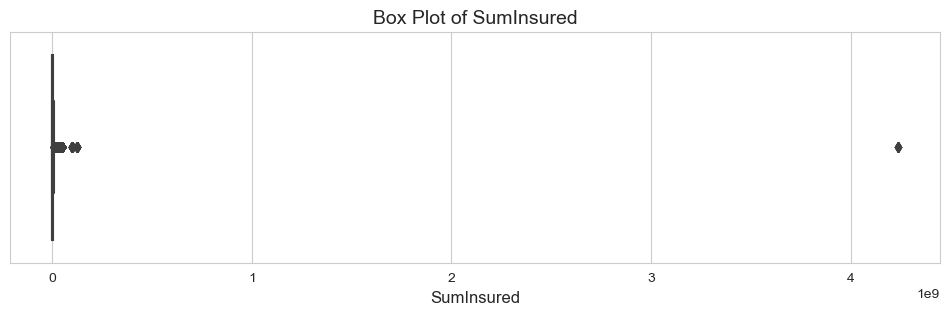

  IQR Method Results for 'SumInsured':
    Q1 (25th percentile): 50,000.00
    Q3 (75th percentile): 2,500,000.00
    IQR (Q3 - Q1): 2,450,000.00
    Lower Bound (Q1 - 1.5*IQR): -3,625,000.00
    Upper Bound (Q3 + 1.5*IQR): 6,175,000.00
    Number of outliers detected: 104592 (10.46% of total data)
    Descriptive statistics of the detected outliers for 'SumInsured':


count       104592.00
mean      50139054.24
std       31804565.17
min        6250000.00
25%       50000000.00
50%       50000000.00
75%       50000000.00
max     4236420313.00
Name: SumInsured, dtype: float64

    Too many outliers (104592) to list individually.

Analyzing column: 'CalculatedPremiumPerTerm'


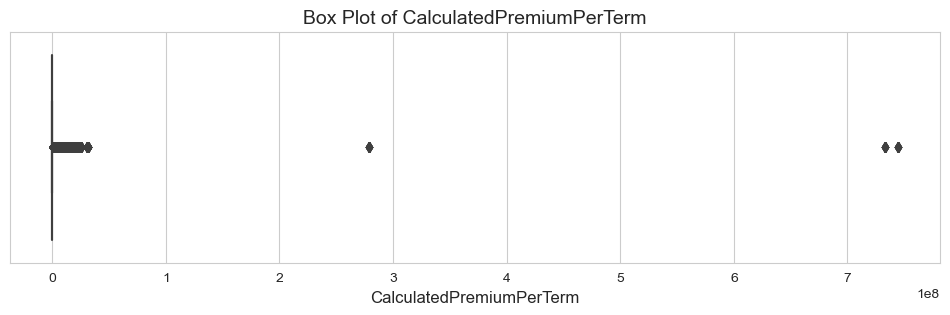

  IQR Method Results for 'CalculatedPremiumPerTerm':
    Q1 (25th percentile): 900.00
    Q3 (75th percentile): 80,597.00
    IQR (Q3 - Q1): 79,697.00
    Lower Bound (Q1 - 1.5*IQR): -118,645.50
    Upper Bound (Q3 + 1.5*IQR): 200,142.50
    Number of outliers detected: 220471 (22.04% of total data)
    Descriptive statistics of the detected outliers for 'CalculatedPremiumPerTerm':


count      220471.00
mean      4201668.03
std       7626421.22
min        200854.00
25%       2087492.00
50%       3165095.00
75%       6104676.00
max     744221679.00
Name: CalculatedPremiumPerTerm, dtype: float64

    Too many outliers (220471) to list individually.

--- Outlier Detection Complete ---
Note: The decision to remove, transform, or cap outliers should be made carefully,
considering the nature of the data and the goals of the analysis/modeling.


In [19]:
print("\n--- Outlier Detection for Financial Columns ---")
print("Identifying and quantifying potential outliers using Box Plots and the IQR Method.")

# Define the list of financial columns to check for outliers
# These are columns that typically represent monetary values or counts.
financial_cols_for_outlier_detection = [
    TOTAL_PREMIUM_COL,
    TOTAL_CLAIMS_COL,
    MARGIN_COL, # Derived column, very important for profitability
    'CustomValueEstimate',
    'CapitalOutstanding',
    'SumInsured',
    'CalculatedPremiumPerTerm'
]

# Filter the list to include only columns that are actually present in the DataFrame
financial_cols_present = [col for col in financial_cols_for_outlier_detection if col in df.columns]

if not financial_cols_present:
    print("No relevant financial columns found in the DataFrame for outlier detection.")
else:
    for col in financial_cols_present:
        print(f"\nAnalyzing column: '{col}'")

        # Basic check to ensure the column is numeric, although Cell 3 should have handled this
        if not pd.api.types.is_numeric_dtype(df[col]):
            print(f"  Warning: Column '{col}' is not numeric. Skipping outlier detection for this column.")
            continue

        # --- Visual Inspection: Box Plot ---
        # Box plots are excellent for visualizing the distribution and potential outliers.
        plt.figure(figsize=(12, 3))
        sns.boxplot(x=df[col])
        plt.title(f'Box Plot of {col}', fontsize=14)
        plt.xlabel(col, fontsize=12)
        plt.show()

        # --- Quantitative Detection: IQR Method ---
        # The IQR method is robust to skewed distributions often found in financial data.
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Outlier bounds: 1.5 * IQR above Q3 or below Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identify outliers based on these bounds
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        num_outliers = len(outliers)
        percentage_outliers = (num_outliers / len(df)) * 100

        print(f"  IQR Method Results for '{col}':")
        print(f"    Q1 (25th percentile): {Q1:,.2f}")
        print(f"    Q3 (75th percentile): {Q3:,.2f}")
        print(f"    IQR (Q3 - Q1): {IQR:,.2f}")
        print(f"    Lower Bound (Q1 - 1.5*IQR): {lower_bound:,.2f}")
        print(f"    Upper Bound (Q3 + 1.5*IQR): {upper_bound:,.2f}")
        print(f"    Number of outliers detected: {num_outliers} ({percentage_outliers:.2f}% of total data)")

        if num_outliers > 0:
            print(f"    Descriptive statistics of the detected outliers for '{col}':")
            display(outliers[col].describe())

            # Optionally print specific outlier values if the count is small
            if num_outliers < 50: # Adjust this threshold as needed
                print(f"    Sample of outlier values for '{col}':")
                print(outliers[col].head(min(num_outliers, 10)).tolist()) # Show up to 10 sample values
            else:
                print(f"    Too many outliers ({num_outliers}) to list individually.")
        else:
            print(f"    No outliers detected for '{col}' using the IQR method.")

print("\n--- Outlier Detection Complete ---")
print("Note: The decision to remove, transform, or cap outliers should be made carefully,")
print("considering the nature of the data and the goals of the analysis/modeling.")

# Creative and Beautiful Plots (Examples)


--- Creative and Beautiful Plots (Examples) ---
Exploring more intricate relationships and distributions with advanced visualizations.

1. Pair Plot for Key Numerical Features with HasClaim Hue:


C:\Users\benke\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


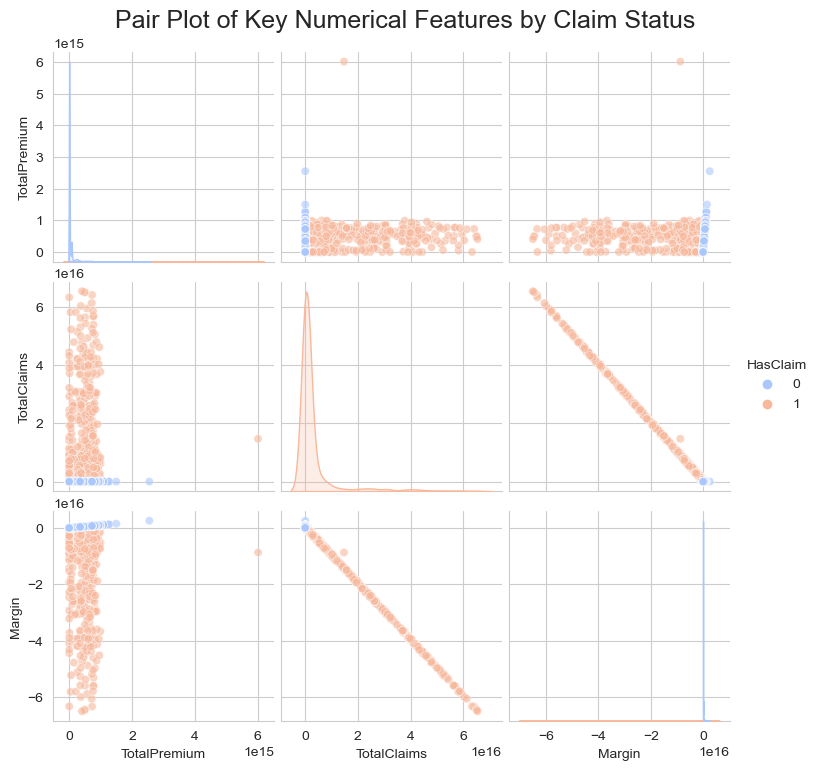


2. Violin Plots of Total Premium and Total Claims by Policy Type & Driver Gender:

3. Enhanced Correlation Heatmap of Numerical Features:


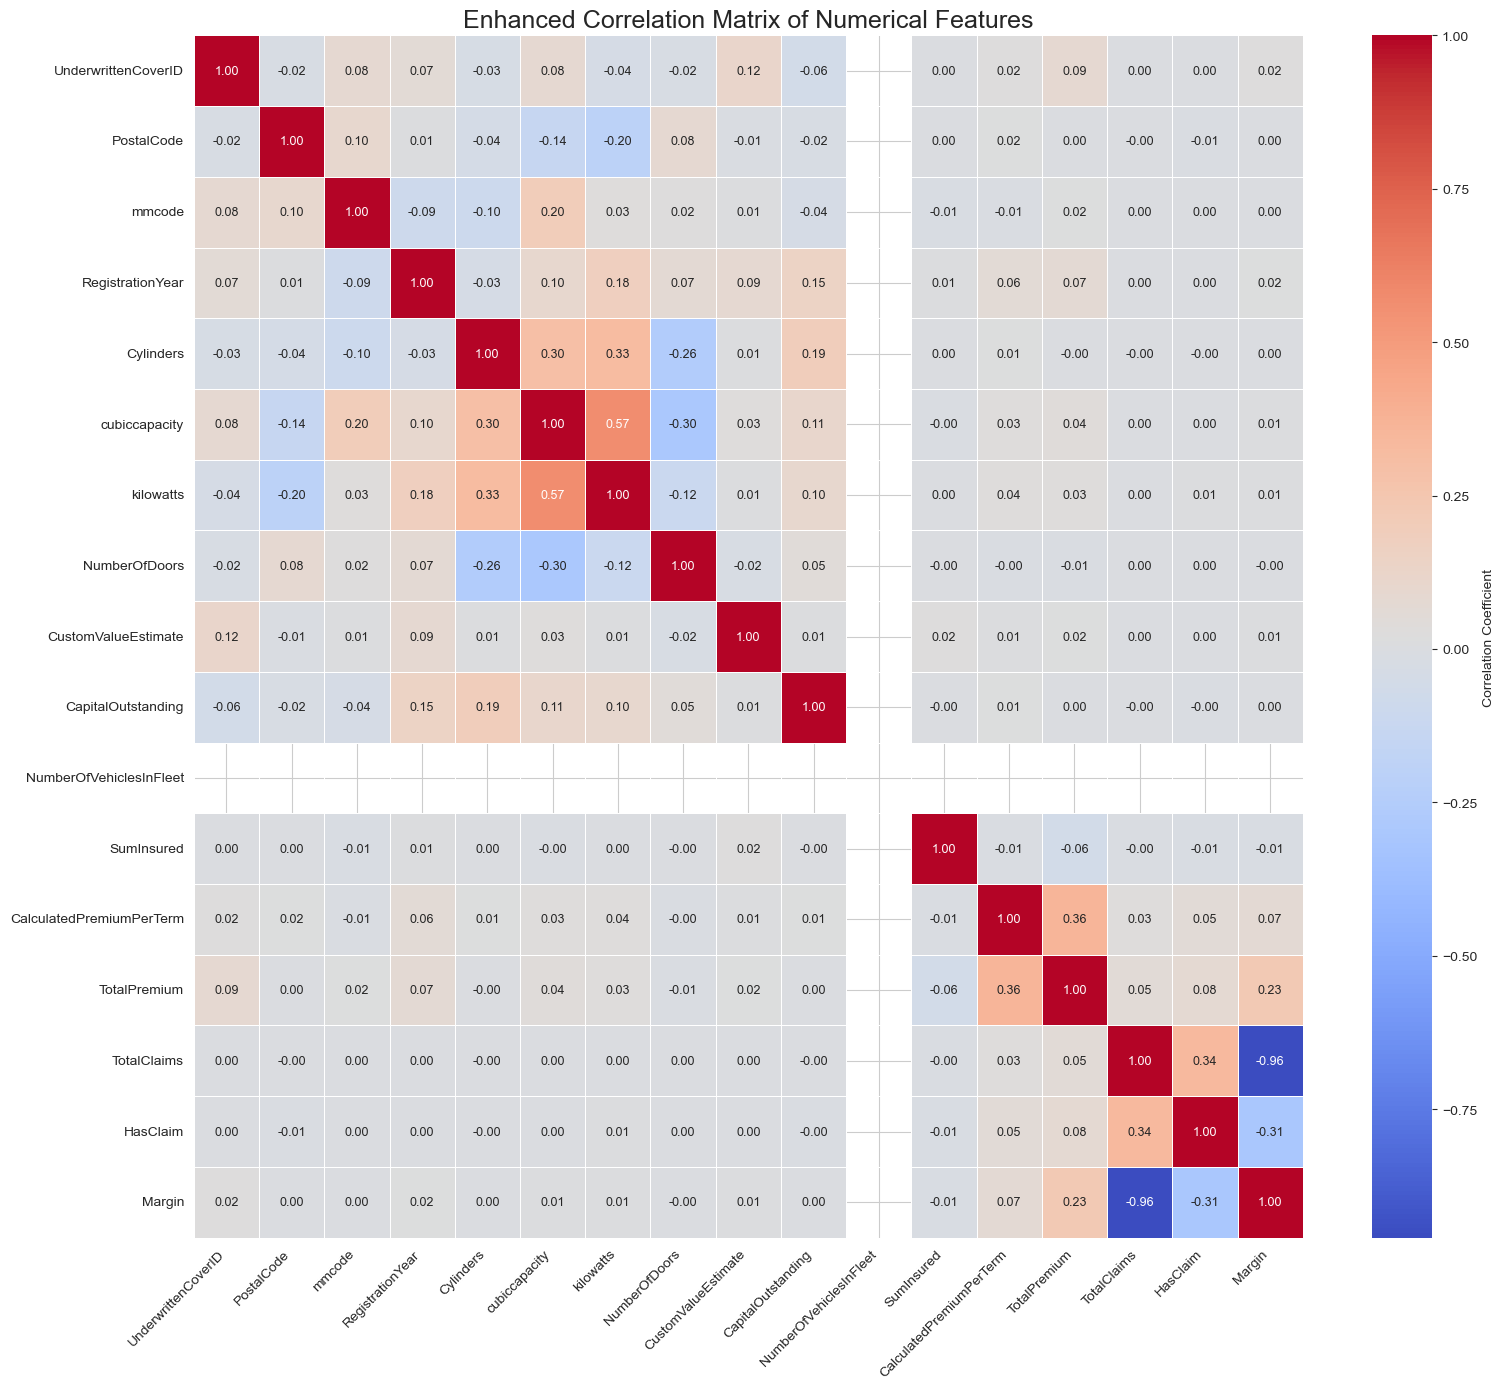


--- Creative and Beautiful Plots Section Complete ---


In [21]:
print("\n--- Creative and Beautiful Plots (Examples) ---")
print("Exploring more intricate relationships and distributions with advanced visualizations.")

# Set a larger figure size for overall plots if desired, or for individual plots.
plt.rcParams['figure.figsize'] = (12, 8) # Adjust as needed
plt.rcParams['figure.dpi'] = 100

# --- Plot 1: Pair Plot (Scatter Matrix) for Key Numerical Features ---
# A pair plot shows scatter plots for all pairs of numerical features
# and histograms/KDEs for individual feature distributions.
# Using 'HasClaim' as hue adds another layer of insight.
print("\n1. Pair Plot for Key Numerical Features with HasClaim Hue:")

# Select a subset of relevant numerical columns to avoid an overly dense plot
numerical_features_for_pairplot = [
    TOTAL_PREMIUM_COL,
    TOTAL_CLAIMS_COL,
    MARGIN_COL,
    'Age',
    'VehicleAge',
    HAS_CLAIM_COL # Keep HasClaim to use as hue
]

# Filter to only include columns present in the DataFrame
pairplot_cols = [col for col in numerical_features_for_pairplot if col in df.columns]

if len(pairplot_cols) > 1 and HAS_CLAIM_COL in df.columns:
    # Drop rows with NaNs in these specific columns for clean plotting
    df_pairplot = df[pairplot_cols].dropna()

    # Cast 'HasClaim' to object/category if not already, for distinct hue colors
    df_pairplot[HAS_CLAIM_COL] = df_pairplot[HAS_CLAIM_COL].astype('category')

    # Create the PairPlot
    # Kind='reg' for scatter plots adds a regression line
    # Diag_kind='kde' for diagonal plots shows density estimates
    sns.pairplot(df_pairplot, hue=HAS_CLAIM_COL, kind='scatter', diag_kind='kde',
                 palette='coolwarm', plot_kws={'alpha': 0.6})
    plt.suptitle('Pair Plot of Key Numerical Features by Claim Status', y=1.02, fontsize=18)
    plt.show()
else:
    print("  Skipping Pair Plot: Not enough numerical columns or 'HasClaim' column missing.")


# --- Plot 2: Violin Plots for Numerical Features Across Categorical Groups ---
# Violin plots show the distribution shape of a numerical variable across categories,
# combining aspects of box plots and kernel density estimation.
print("\n2. Violin Plots of Total Premium and Total Claims by Policy Type & Driver Gender:")

# Ensure these columns exist
if TOTAL_PREMIUM_COL in df.columns and TOTAL_CLAIMS_COL in df.columns:
    # Violin Plot: Total Premium by PolicyType
    if 'PolicyType' in df.columns:
        plt.figure(figsize=(14, 7))
        sns.violinplot(x='PolicyType', y=TOTAL_PREMIUM_COL, data=df, palette='pastel', inner='quartile')
        plt.title(f'Distribution of {TOTAL_PREMIUM_COL} by Policy Type', fontsize=16)
        plt.xlabel('Policy Type', fontsize=12)
        plt.ylabel('Total Premium (Log Scale)', fontsize=12)
        plt.yscale('log') # Log scale often helps with skewed financial data
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

    # Violin Plot: Total Claims by DriverGender
    if 'DriverGender' in df.columns:
        plt.figure(figsize=(10, 6))
        sns.violinplot(x='DriverGender', y=TOTAL_CLAIMS_COL, data=df[df[TOTAL_CLAIMS_COL] > 0], palette='muted', inner='quartile')
        plt.title(f'Distribution of {TOTAL_CLAIMS_COL} by Driver Gender (for claims > 0)', fontsize=16)
        plt.xlabel('Driver Gender', fontsize=12)
        plt.ylabel('Total Claims (Log Scale)', fontsize=12)
        plt.yscale('log') # Log scale is crucial for claims data
        plt.tight_layout()
        plt.show()
else:
    print(f"  Skipping Violin Plots: '{TOTAL_PREMIUM_COL}' or '{TOTAL_CLAIMS_COL}' columns missing.")


# --- Plot 3: Enhanced Correlation Heatmap ---
# A larger, more readable heatmap with a good color scheme and annotated values.
print("\n3. Enhanced Correlation Heatmap of Numerical Features:")

# Select only numerical columns for correlation matrix (excluding ID if it's numeric)
numeric_df_corr = df.select_dtypes(include=np.number).copy()
if POLICY_ID_COL in numeric_df_corr.columns:
    numeric_df_corr = numeric_df_corr.drop(columns=[POLICY_ID_COL])

if not numeric_df_corr.empty:
    correlation_matrix = numeric_df_corr.corr()

    plt.figure(figsize=(16, 14)) # Adjust size based on number of features
    sns.heatmap(
        correlation_matrix,
        annot=True,       # Show correlation values on the map
        cmap='coolwarm',  # Color map ('coolwarm' for diverging)
        fmt=".2f",        # Format annotations to 2 decimal places
        linewidths=.5,    # Lines between cells
        cbar_kws={'label': 'Correlation Coefficient'}, # Color bar label
        annot_kws={"size": 9} # Font size for annotations
    )
    plt.title('Enhanced Correlation Matrix of Numerical Features', fontsize=18)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("  Skipping Enhanced Correlation Heatmap: No numerical columns found or only one numerical column.")

print("\n--- Creative and Beautiful Plots Section Complete ---")